**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Erick Gabriel Santiago Suenaga

## Práctica 1: Análisis exploratorio de dataset

---

## Contexto y procedencia del dataset

El conjunto de datos de Mortalidad por Accidente Cerebrovascular (Stroke) en adultos de EE. UU., 2015–2017 reporta la tasa de mortalidad por accidente cerebrovascular (ACV / stroke), ajustada por edad, expresada en muertes por cada 100,000 habitantes, para la población adulta de 35 años o más en Estados Unidos. La tasa reportada es un promedio de 3 años (2015–2017).

Los datos provienen del **National Vital Statistics System (NVSS)**, el sistema que recopila los certificados de defunción en Estados Unidos, y fueron procesados y publicados por la **División para la Prevención de Enfermedades del Corazón y el Accidente Cerebrovascular (DHDSP)** de los **CDC (Centers for Disease Control and Prevention)**.

El archivo original ("Stroke Mortality Data Among US Adults (35+) by State/Territory and County – 2015-2017") fue publicado en el portal oficial data.cdc.gov el 14 de julio de 2023. La versión que se utilizó es una copia republicada en Kaggle por el usuario "thedevastator" bajo el título "US Stroke Mortality in Adults Over 35 (2015-2017)".

Cada fila corresponde a una combinación única de:
- Un **área geográfica** (nación, estado / territorio o condado),
- Un **sexo** (Total / Hombres / Mujeres), y
- Un **grupo racial o étnico** (Total / Blanca / Negra / Hispana / Asiática-Isleña del Pacífico / Indígena americana-nativa de Alaska),

para el periodo 2015–2017. **No** es un registro de personas individuales; es una tasa agregada por subgrupo poblacional y área geográfica.

**Fuente, enlaces y licencia:**
- Fuente original: https://data.cdc.gov (dataset "Stroke Mortality Data Among US Adults (35+) by State/Territory and County – 2015-2017"), distribuido bajo **Open Data Commons Attribution License (ODC-BY 1.0)**.
- Copia usada en esta práctica (Kaggle): https://www.kaggle.com/datasets/thedevastator/us-stroke-mortality-in-adults-over-35-2015-2017

**Nota:** es un dataset de salud pública real (no es un conjunto didáctico como *iris* o *titanic*), producido para vigilancia epidemiológica. Por lo tanto trae consigo limitaciones típicas de datos administrativos reales: valores faltantes por confidencialidad estadística, tasas inestables cuando el número de casos es pequeño, y columnas con distinto nivel de detalle geográfico mezcladas en la misma tabla.

## Preparación del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

numpy      2.1.3
pandas     2.2.3
matplotlib 3.10.0
seaborn    0.13.2


Configuramos algunas opciones de estilo para las gráficas del notebook. Los colores se escriben directamente como códigos hexadecimales en cada gráfica (por ejemplo, cualquier color válido de matplotlib serviría en su lugar).

In [2]:
sns.set_theme(style="whitegrid", palette=["#112057", "#4C72B0", "#A9C4E8", "#C0392B"])
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlecolor"] = "#112057"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

## Carga de datos

El archivo `csv-1.csv` es la descarga directa del dataset descrito arriba, sin ninguna modificación previa. Solo eliminamos la columna `index`, que es redundante con el índice que pandas asigna automáticamente a cada fila.

In [3]:
df = pd.read_csv("csv-1.csv")
df = df.drop(columns=["index"])

print("Filas y columnas:", df.shape)
print(df.head(3).to_string())

Filas y columnas: (59094, 23)
   Year LocationAbbr   LocationDesc GeographicLevel DataSource                    Class             Topic  Data_Value         Data_Value_Unit                                        Data_Value_Type Data_Value_Footnote_Symbol Data_Value_Footnote StratificationCategory1 Stratification1 StratificationCategory2 Stratification2 TopicID  LocationID      Y_lat       X_lon               Georeferenced Column  States  Counties
0  2016           AZ        Arizona           State       NVSS  Cardiovascular Diseases  Stroke Mortality        58.3  per 100,000 population                      Age-adjusted, 3-year Average Rate                        NaN                 NaN                  Gender          Female          Race/Ethnicity        Hispanic      T6           4  34.292100 -111.664000           POINT (-111.664 34.2921)     7.0     987.0
1  2016           GA        Georgia           State       NVSS  Cardiovascular Diseases  Stroke Mortality        81.0  per 100,000

## Verificación de estructura y cumplimiento de requisitos

In [4]:
print("=" * 70)
print("VERIFICACIÓN DE REQUISITOS MÍNIMOS DEL DATASET")
print("=" * 70)

n_filas, n_cols = df.shape
print(f"\n1) Registros y atributos")
print(f"   Filas: {n_filas:,} | Columnas: {n_cols}")
print(f"   ¿Cumple (>=500 filas y >=10 columnas)? {n_filas >= 500 and n_cols >= 10}")

num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
print(f"\n2) Tipos de atributos")
print(f"   Numéricos ({len(num_cols)}): {num_cols}")
print(f"   Categóricos ({len(cat_cols)}): {cat_cols}")
print(f"   ¿Cumple (>=2 numéricos y >=2 categóricos)? {len(num_cols) >= 2 and len(cat_cols) >= 2}")

print(f"\n3) Variable objetivo candidata")
print("   'Data_Value' (tasa de mortalidad por ACV por 100,000 hab.) puede usarse")
print("   como variable objetivo continua para un problema de regresión, o bien")
print("   discretizarse (p. ej. por encima/por debajo de la mediana nacional)")
print("   para un problema de clasificación.")

faltantes = df.isnull().sum().sum()
duplicados = df.duplicated().sum()
fuera_rango = int((df["Data_Value"] < 0).sum() + (df["Data_Value"] > 1000).sum())
print(f"\n4) Condiciones de datos reales")
print(f"   Valores faltantes totales: {faltantes:,} ({faltantes / df.size * 100:.1f}% de todas las celdas)")
print(f"   Filas duplicadas (idénticas): {duplicados}")
print(f"   Valores de tasa fuera de rango plausible (<0 ó >1000): {fuera_rango}")
print("   -> Además, 'States' y 'Counties' son códigos identificadores (FIPS) que")
print("      quedaron tipificados como 'float' en lugar de categóricos: una")
print("      inconsistencia de codificación que se revisa en la sección 5.")
cumple_condicion_real = bool(faltantes > 0 or duplicados > 0 or fuera_rango > 0)
print(f"   ¿Cumple (al menos una condición de dato real presente)? {cumple_condicion_real}")

print(f"\n5) Procedencia verificable")
print("   Fuente: CDC / National Vital Statistics System (data.cdc.gov, id v246-z5tb)")
print("   Periodo/fecha de publicación: datos 2015-2017, publicados el 2023-07-14")
print("   Unidad de observación: área geográfica x sexo x grupo racial/étnico")
print("   Licencia: Open Data Commons Attribution License (ODC-BY 1.0)")
print("   Enlace Kaggle: https://www.kaggle.com/datasets/thedevastator/us-stroke-mortality-in-adults-over-35-2015-2017")

VERIFICACIÓN DE REQUISITOS MÍNIMOS DEL DATASET

1) Registros y atributos
   Filas: 59,094 | Columnas: 23
   ¿Cumple (>=500 filas y >=10 columnas)? True

2) Tipos de atributos
   Numéricos (7): ['Year', 'Data_Value', 'LocationID', 'Y_lat', 'X_lon', 'States', 'Counties']
   Categóricos (16): ['LocationAbbr', 'LocationDesc', 'GeographicLevel', 'DataSource', 'Class', 'Topic', 'Data_Value_Unit', 'Data_Value_Type', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote', 'StratificationCategory1', 'Stratification1', 'StratificationCategory2', 'Stratification2', 'TopicID', 'Georeferenced Column']
   ¿Cumple (>=2 numéricos y >=2 categóricos)? True

3) Variable objetivo candidata
   'Data_Value' (tasa de mortalidad por ACV por 100,000 hab.) puede usarse
   como variable objetivo continua para un problema de regresión, o bien
   discretizarse (p. ej. por encima/por debajo de la mediana nacional)
   para un problema de clasificación.

4) Condiciones de datos reales
   Valores faltantes totales: 89,17

El dataset cumple con los requisitos, tiene más de 500 filas y 10 columnas, mezcla atributos numéricos y categóricos, ofrece una variable candidata a objetivo y presenta condiciones reales de datos (valores faltantes e inconsistencias de tipificación), con procedencia verificable y con licencia clara.

### Dimensiones y tipo de cada atributo

In [5]:
print(df.dtypes)
print()
df.info()

Year                            int64
LocationAbbr                   object
LocationDesc                   object
GeographicLevel                object
DataSource                     object
Class                          object
Topic                          object
Data_Value                    float64
Data_Value_Unit                object
Data_Value_Type                object
Data_Value_Footnote_Symbol     object
Data_Value_Footnote            object
StratificationCategory1        object
Stratification1                object
StratificationCategory2        object
Stratification2                object
TopicID                        object
LocationID                      int64
Y_lat                         float64
X_lon                         float64
Georeferenced Column           object
States                        float64
Counties                      float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59094 entries, 0 to 59093
Data columns (total 23 columns):
 #

**Diccionario de columnas**

| Columna | Descripción |
|---|---|
| `Year` | Año de referencia del promedio (2016 = punto central del periodo 2015–2017) |
| `LocationAbbr` | Abreviatura de la ubicación (código de estado, o "US" para el nivel nacional) |
| `LocationDesc` | Nombre de la ubicación (país, estado o condado) |
| `GeographicLevel` | Nivel geográfico del registro: `Nation`, `State` o `County` |
| `DataSource` | Fuente de los datos (siempre `NVSS`) |
| `Class` | Categoría de enfermedad (siempre `Cardiovascular Diseases`) |
| `Topic` | Tema específico (siempre `Stroke Mortality`) |
| `Data_Value` | **Tasa de mortalidad por 100,000 habitantes (variable de interés / posible objetivo)** |
| `Data_Value_Unit` | Unidad de la tasa (siempre `per 100,000 population`) |
| `Data_Value_Type` | Tipo de tasa: ajustada por edad, con o sin suavizado espacial |
| `Data_Value_Footnote_Symbol` / `Data_Value_Footnote` | Marca y texto que explican por qué el valor es nulo (`Insufficient Data`) |
| `StratificationCategory1` / `Stratification1` | Categoría y valor del desglose por **sexo** |
| `StratificationCategory2` / `Stratification2` | Categoría y valor del desglose por **raza/etnia** |
| `TopicID` | Código interno del tema |
| `LocationID` | Código numérico (tipo FIPS) de la ubicación |
| `Y_lat` / `X_lon` | Coordenadas del centroide de la ubicación |
| `Georeferenced Column` | Representación en formato WKT de las mismas coordenadas |
| `States` / `Counties` | Códigos numéricos (tipo FIPS) de estado y de condado |

El dataset tiene 59,094 filas y 23 columnas (tras eliminar `index`). Hay 7 columnas numéricas y 16 categóricas. Solo `Data_Value` tiene una cantidad importante de valores nulos (más del 50%); el resto de las columnas están casi completas. `LocationID`, `States` y `Counties` aparecen como `float64`/`int64`, pero en realidad son códigos identificadores, no cantidades: no se deben sumar o promediar estos datos.

## Calidad de los datos

### Registros duplicados

In [6]:
print("Filas totales:", len(df))
print("Duplicados exactos (todas las columnas):", df.duplicated().sum())

# Duplicados respecto a la llave conceptual del dataset: ubicación x sexo x raza/etnia
llave = ["LocationID", "Stratification1", "Stratification2"]
print("Duplicados por llave (ubicación, sexo, raza/etnia):", df.duplicated(subset=llave).sum())

print("\nÁreas geográficas únicas:", df["LocationID"].nunique())
print("Filas por área geográfica (debería ser 3 sexos x 6 razas = 18):")
print(df.groupby("LocationID").size().value_counts())

Filas totales: 59094
Duplicados exactos (todas las columnas): 0
Duplicados por llave (ubicación, sexo, raza/etnia): 0

Áreas geográficas únicas: 3283
Filas por área geográfica (debería ser 3 sexos x 6 razas = 18):
18    3283
Name: count, dtype: int64


No existen filas duplicadas, ni de forma exacta ni respecto a la llave conceptual (área x sexo x raza / etnia). Esto se explica porque el dataset no es una muestra aleatoria, es una tabla construida por diseño, no por muestreo.

### Patrón de valores faltantes

In [7]:
faltantes_col = df.isnull().sum()
faltantes_pct = (faltantes_col / len(df) * 100).round(1)
resumen_na = pd.DataFrame({"faltantes": faltantes_col, "pct_faltantes": faltantes_pct})
print(resumen_na[resumen_na.faltantes > 0].sort_values("faltantes", ascending=False))

                            faltantes  pct_faltantes
Data_Value                      31098           52.6
Data_Value_Footnote_Symbol      27996           47.4
Data_Value_Footnote             27996           47.4
States                           1800            3.0
Counties                          234            0.4
Y_lat                              18            0.0
Georeferenced Column               18            0.0
X_lon                              18            0.0


GeographicLevel
County    53.0
State     30.0
Nation     0.0
Name: Data_Value, dtype: float64


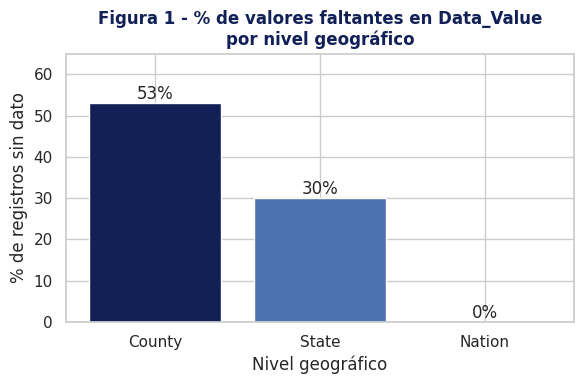

In [8]:
pct_na_por_nivel = (
    df.groupby("GeographicLevel")["Data_Value"]
    .apply(lambda s: s.isnull().mean() * 100)
    .sort_values(ascending=False)
)
print(pct_na_por_nivel.round(1))

plt.figure(figsize=(6, 4))
plt.bar(pct_na_por_nivel.index, pct_na_por_nivel.values,
        color=["#112057", "#4C72B0", "#A9C4E8"])
plt.title("Figura 1 - % de valores faltantes en Data_Value\npor nivel geográfico")
plt.ylabel("% de registros sin dato")
plt.xlabel("Nivel geográfico")
for i, v in enumerate(pct_na_por_nivel.values):
    plt.text(i, v + 1, f"{v:.0f}%", ha="center")
plt.ylim(0, 65)
plt.tight_layout()

**Figura 1.** El 52.6% de los 59,094 registros no tiene valor de tasa (`Data_Value` nulo), y en todos los casos viene acompañado de la nota `Insufficient Data`: los CDC suprimen la tasa cuando el número de defunciones registradas es demasiado bajo para producir una estimación confiable o para proteger la confidencialidad de grupos pequeños.

### Cardinalidad de los atributos categóricos

In [9]:
cat_cols_interes = ["GeographicLevel", "LocationAbbr", "LocationDesc",
                     "Data_Value_Type", "Stratification1", "Stratification2"]
for c in cat_cols_interes:
    print(f"{c:18s}: {df[c].nunique():5d} categorías únicas")

GeographicLevel   :     3 categorías únicas
LocationAbbr      :    57 categorías únicas
LocationDesc      :  2023 categorías únicas
Data_Value_Type   :     2 categorías únicas
Stratification1   :     3 categorías únicas
Stratification2   :     6 categorías únicas


`Stratification1` (sexo, 3 categorías) y `Stratification2` (raza/etnia, 6 categorías) tienen baja cardinalidad y están perfectamente balanceadas por diseño. `GeographicLevel` solo tiene 3 valores, pero `LocationDesc` tiene 2,023 nombres únicos porque **nombres de condado se repiten en distintos estados** (por ejemplo, existen varios "Washington County"); esto es una inconsistencia a tener en cuenta: `LocationDesc` **no** es una llave segura para identificar una ubicación, hay que usar `LocationID` o la pareja `LocationAbbr` + `LocationDesc`. `LocationAbbr` tiene 57 valores porque, además de los 50 estados y el Distrito de Columbia, incluye territorios (Puerto Rico, Guam, Samoa Americana, Islas Marianas del Norte, Islas Vírgenes) y el código nacional `US`.

### Valores imposibles o fuera de rango

In [10]:
print("Tasas negativas:", (df["Data_Value"] < 0).sum())
print("Tasas mayores a 1000 por 100,000 (implausibles):", (df["Data_Value"] > 1000).sum())
print("Tasa máxima observada:", df["Data_Value"].max(), " | mínima:", df["Data_Value"].min())

print("\nCoordenadas en (0, 0) ('isla nula', error típico de geocodificación):",
      ((df.Y_lat == 0) & (df.X_lon == 0)).sum())
print("Rango de latitud :", df.Y_lat.min(), "a", df.Y_lat.max())
print("Rango de longitud:", df.X_lon.min(), "a", df.X_lon.max())

extremos = df[df.Data_Value > 300][
    ["LocationDesc", "LocationAbbr", "GeographicLevel", "Stratification1", "Stratification2", "Data_Value"]
]
print("\nRegistros con tasa > 300 por 100,000 (posible inestabilidad estadística):")
print(extremos.to_string(index=False))

Tasas negativas: 0
Tasas mayores a 1000 por 100,000 (implausibles): 0
Tasa máxima observada: 508.9  | mínima: 0.0

Coordenadas en (0, 0) ('isla nula', error típico de geocodificación): 0
Rango de latitud : -14.30175426 a 69.309529075
Rango de longitud: -170.7194738 a 145.75125879

Registros con tasa > 300 por 100,000 (posible inestabilidad estadística):
       LocationDesc LocationAbbr GeographicLevel Stratification1            Stratification2  Data_Value
       Logan County           IL          County          Female                      Black       450.1
      Morgan County           IL          County            Male                      Black       508.9
     Madison County           IL          County            Male Asian and Pacific Islander       436.6
       Logan County           IL          County         Overall                      Black       313.5
   Catahoula Parish           LA          County            Male                      Black       333.9
Spotsylvania County 

No hay tasas negativas ni valores fuera de rango (>1000 por 100,000), y no hay coordenadas en (0,0). Sin embargo, existen **6 registros de condado con tasas superiores a 300 por 100,000** (hasta 508.9 en el condado de Morgan, Illinois, para hombres de raza negra). En todos los casos se trata de un subgrupo racial minoritario dentro de un condado pequeño. Estos valores no son errores de captura, pero sí requieren tratamiento especial antes de usarse para comparar condados entre sí.

## Análisis univariado

Nos concentramos en los atributos más relevantes para el problema: la variable numérica `Data_Value` (la tasa de mortalidad, y candidata a variable objetivo) y las variables categóricas de estratificación `GeographicLevel`, `Stratification1` (sexo) y `Stratification2` (raza/etnia).

In [11]:
print(df["Data_Value"].describe().round(2))
print()
print(df.groupby("Data_Value_Type")["Data_Value"].describe()[["count", "mean", "50%", "std"]].round(2))

count    27996.00
mean        79.53
std         26.06
min          0.00
25%         64.30
50%         75.90
75%         90.60
max        508.90
Name: Data_Value, dtype: float64

                                                      count   mean    50%    std
Data_Value_Type                                                                 
Age-adjusted, 3-year Average Rate                     724.0  73.50  70.65  23.56
Age-adjusted, Spatially Smoothed, 3-year Averag...  27272.0  79.69  76.10  26.10


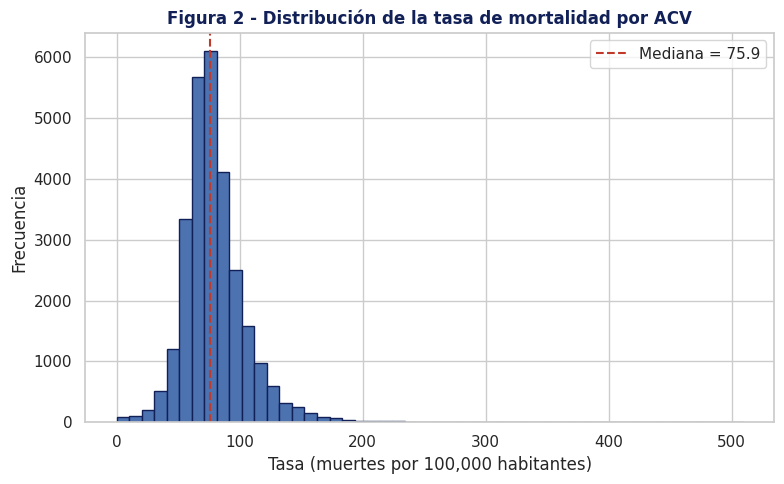

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["Data_Value"].dropna(), bins=50, color="#4C72B0", edgecolor="#112057")
plt.axvline(df["Data_Value"].median(), color="#C0392B", linestyle="--",
            label=f"Mediana = {df['Data_Value'].median():.1f}")
plt.title("Figura 2 - Distribución de la tasa de mortalidad por ACV")
plt.xlabel("Tasa (muertes por 100,000 habitantes)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

**Figura 2.** De los 27,996 registros con valor reportado, la tasa promedio es 79.5 y la mediana 75.9 (la media es mayor que la mediana), con una distribución **unimodal y con sesgo positivo** (cola larga hacia la derecha): la mayoría de los valores se concentra entre 64 y 91 (rango intercuartílico), pero existe una cola de valores altos —hasta 508.9— generada sobre todo por los registros de condado con subgrupos pequeños descritos en la sección anterior. Para resumir esta variable conviene usar la mediana y el rango intercuartílico en lugar de la media, que es más sensible a esos valores extremos.

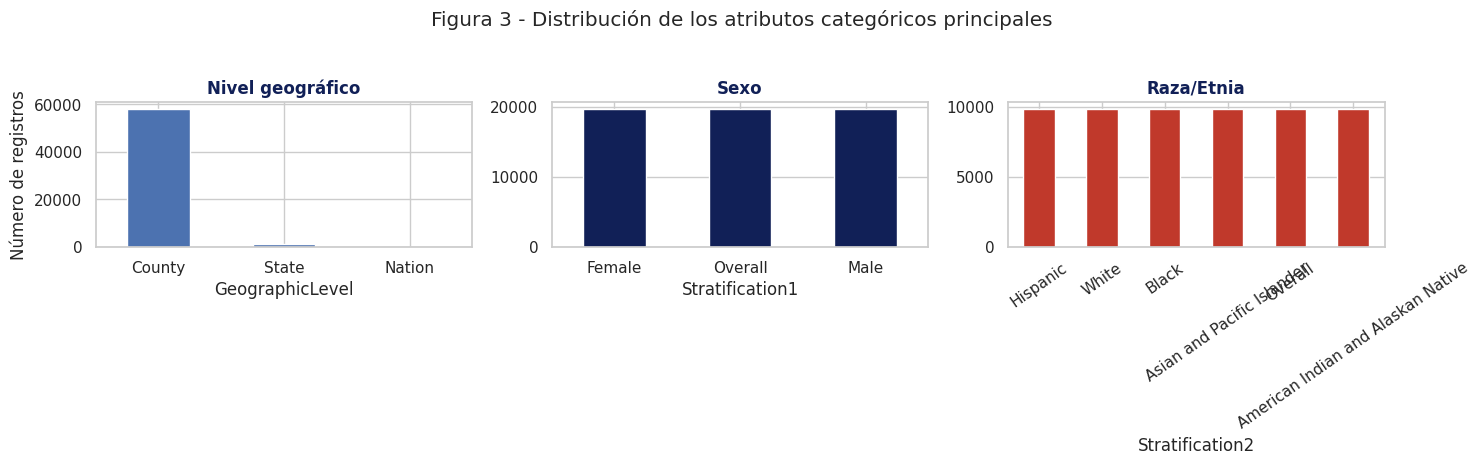

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

df["GeographicLevel"].value_counts().plot(kind="bar", ax=axs[0], color="#4C72B0")
axs[0].set_title("Nivel geográfico")
axs[0].set_ylabel("Número de registros")
axs[0].tick_params(axis="x", rotation=0)

df["Stratification1"].value_counts().plot(kind="bar", ax=axs[1], color="#112057")
axs[1].set_title("Sexo")
axs[1].tick_params(axis="x", rotation=0)

df["Stratification2"].value_counts().plot(kind="bar", ax=axs[2], color="#C0392B")
axs[2].set_title("Raza/Etnia")
axs[2].tick_params(axis="x", rotation=35)

fig.suptitle("Figura 3 - Distribución de los atributos categóricos principales", y=1.03)
plt.tight_layout()
plt.show()

**Figura 3.** `GeographicLevel` está dominado por registros de condado (58,068 de 59,094, ≈98%), frente a solo 1,008 estatales y 18 nacionales: esto refleja el nivel de detalle geográfico con el que se construyó la tabla, no la importancia relativa de cada nivel. En cambio, `Stratification1` (sexo) y `Stratification2` (raza/etnia) están **perfectamente balanceadas** (19,698 filas por cada sexo; 9,849 por cada grupo racial): esto confirma, como en la sección 5.1, que el dataset es un cruce factorial diseñado y no una muestra que refleje la composición demográfica real de Estados Unidos.

## Análisis bivariado

Explorando `Data_Value` frente a **sexo** y frente a **raza/etnia**, ambos son de los determinantes sociodemográficos mejor documentados en la literatura epidemiológica sobre enfermedad cerebrovascular, y el diseño del dataset permite compararlos directamente. Para evitar el ruido de las tasas de condado con muestras pequeñas, estas comparaciones se hacen a nivel estatal, que tiene denominadores poblacionales mucho más grandes y por lo tanto tasas más estables.

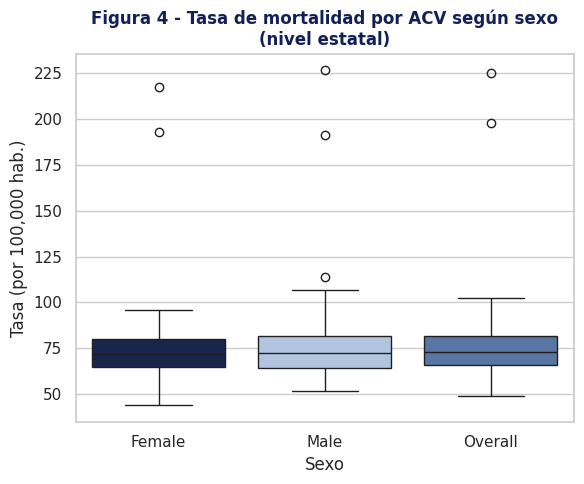

Stratification1
Female     72.05
Male       72.60
Overall    73.15
Name: Data_Value, dtype: float64


In [14]:
estado = df[df.GeographicLevel == "State"]
datos_sexo = estado[estado.Stratification2 == "Overall"]

plt.figure(figsize=(6, 5))
sns.boxplot(data=datos_sexo, x="Stratification1", y="Data_Value",
            order=["Female", "Male", "Overall"], hue="Stratification1",
            palette=["#A9C4E8", "#4C72B0", "#112057"], legend=False)
plt.title("Figura 4 - Tasa de mortalidad por ACV según sexo\n(nivel estatal)")
plt.xlabel("Sexo")
plt.ylabel("Tasa (por 100,000 hab.)")
plt.tight_layout()
plt.show()

print(datos_sexo.groupby("Stratification1")["Data_Value"].median())

**Figura 4.** A nivel estatal, las medianas por sexo son muy cercanas: 72.05 (mujeres), 72.60 (hombres) y 73.15 (total). La diferencia entre hombres y mujeres es pequeña. Una explicación posible es que, al tratarse de una tasa de mortalidad ajustada por edad, una parte de la brecha por sexo que se observa en incidencia bruta queda atenuada, también es posible que la brecha sea más visible a nivel de condado que a nivel estatal.

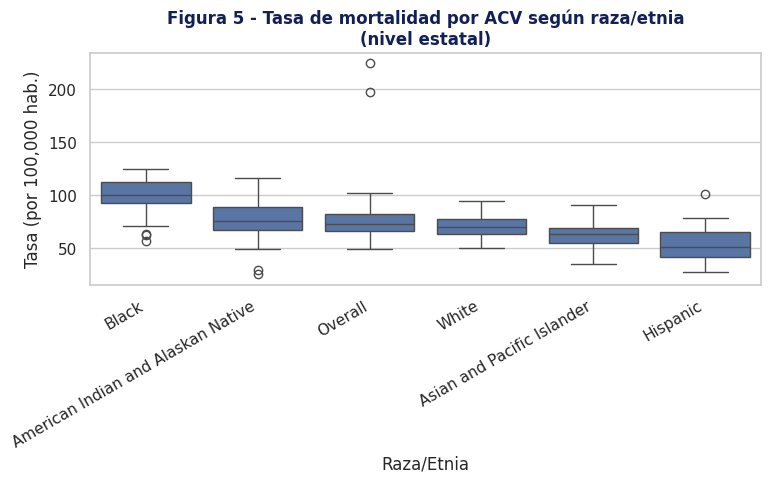

Stratification2
Black                                 99.85
American Indian and Alaskan Native    75.60
Overall                               73.15
White                                 70.30
Asian and Pacific Islander            63.50
Hispanic                              50.65
Name: Data_Value, dtype: float64


In [15]:
datos_raza = estado[estado.Stratification1 == "Overall"]
orden_raza = (
    datos_raza.groupby("Stratification2")["Data_Value"].median()
    .sort_values(ascending=False).index
)

plt.figure(figsize=(8, 5))
sns.boxplot(data=datos_raza, x="Stratification2", y="Data_Value",
            order=orden_raza, color="#4C72B0")
plt.title("Figura 5 - Tasa de mortalidad por ACV según raza/etnia\n(nivel estatal)")
plt.xlabel("Raza/Etnia")
plt.ylabel("Tasa (por 100,000 hab.)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(datos_raza.groupby("Stratification2")["Data_Value"].median().sort_values(ascending=False))

**Figura 5.** Aquí sí aparece una disparidad clara: la mediana de la población **negra (99.85)** casi duplica la de la población **hispana (50.65)**, con la población **indígena americana/nativa de Alaska (75.60)**, el **total (73.15)**, la población **blanca (70.30)** y la población **asiática/isleña del Pacífico (63.50)** en posiciones intermedias. Esta disparidad es consistente con lo reportado ampliamente en la literatura de salud pública de EE. UU. sobre inequidades cardiovasculares en la población afroamericana (aunque el dataset no incluye las variables —acceso a salud, comorbilidades, nivel socioeconómico— necesarias para explicar *por qué* ocurre). También se observa una superposición considerable entre las cajas: la raza/etnia por sí sola no separa completamente los estados con tasas altas de los de tasas bajas, hay más variabilidad dentro de cada grupo que lo que sugieren únicamente las medianas.

## Vista multivariada

Primero se revisa si existe relación lineal entre las variables numéricas continuas (es excluye `LocationID`, `States` y `Counties`, que son códigos identificadores y no cantidades). Después se construye un mapa de dispersión geográfico usando el color como tercera dimensión para visualizar la tasa de mortalidad en el espacio.

            Data_Value  Y_lat  X_lon
Data_Value        1.00  -0.22   0.05
Y_lat            -0.22   1.00  -0.36
X_lon             0.05  -0.36   1.00


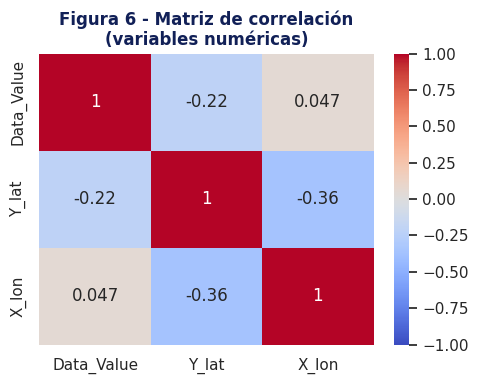

In [16]:
num_relevantes = df[["Data_Value", "Y_lat", "X_lon"]]
corr = num_relevantes.corr()
print(corr.round(2))

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Figura 6 - Matriz de correlación\n(variables numéricas)")
plt.tight_layout()
plt.show()

**Figura 6.** Las correlaciones son, en general, débiles. `Data_Value` tiene una correlación negativa moderada con la latitud (-0.22): a menor latitud (más al sur) tiende a haber tasas más altas, algo que se confirma visualmente en la siguiente figura. La correlación con la longitud es prácticamente nula (0.05). La correlación entre latitud y longitud (-0.36) solo refleja la geografía del territorio de EE. UU. (los estados del sur tienden a estar más al este) y no aporta información sustantiva. En conjunto, esto sugiere que la variable numérica que más "explica" a `Data_Value` dentro de este conjunto no es otra variable numérica, sino las categorías de estratificación (sexo, raza/etnia) vistas en la sección anterior.

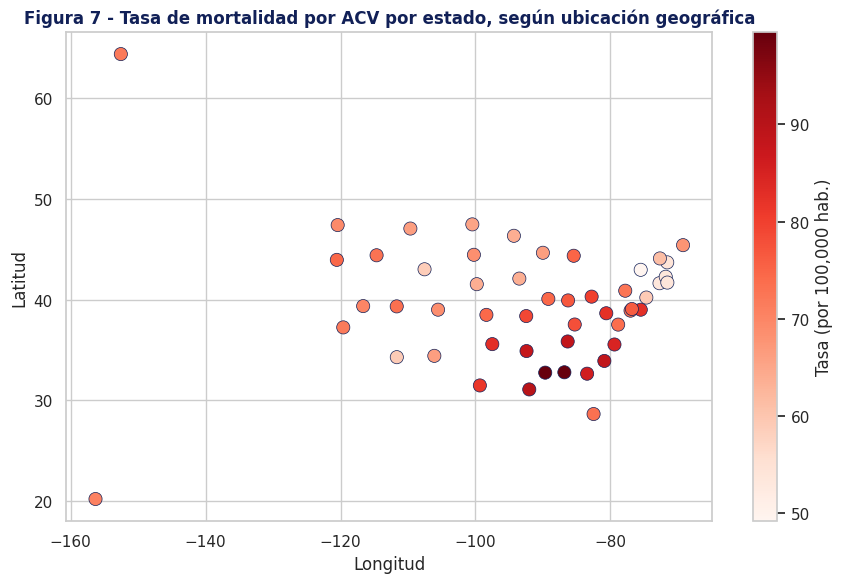

Estados con mayor tasa:
  LocationDesc  Data_Value
   Mississippi        99.5
       Alabama        99.4
     Louisiana        89.9
South Carolina        88.5
     Tennessee        88.4

Estados con menor tasa:
 LocationDesc  Data_Value
     New York        49.2
  Connecticut        53.4
Massachusetts        53.6
 Rhode Island        53.8
New Hampshire        54.2


In [17]:
territorios = ["AS", "GU", "MP", "PR", "VI", "US"]
mapa_datos = estado[
    (estado.Stratification1 == "Overall")
    & (estado.Stratification2 == "Overall")
    & (~estado.LocationAbbr.isin(territorios))
].dropna(subset=["Data_Value"])
# Excluimos territorios: sus coordenadas extremas distorsionarían el mapa
# y, al tener poblaciones muy pequeñas, sus tasas son poco estables.

plt.figure(figsize=(9, 6))
sc = plt.scatter(mapa_datos["X_lon"], mapa_datos["Y_lat"], c=mapa_datos["Data_Value"],
                  cmap="Reds", s=90, edgecolor="#112057", linewidth=0.5)
plt.colorbar(sc, label="Tasa (por 100,000 hab.)")
plt.title("Figura 7 - Tasa de mortalidad por ACV por estado, según ubicación geográfica")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()

print("Estados con mayor tasa:")
print(mapa_datos.sort_values("Data_Value", ascending=False).head(5)[["LocationDesc", "Data_Value"]].to_string(index=False))
print("\nEstados con menor tasa:")
print(mapa_datos.sort_values("Data_Value").head(5)[["LocationDesc", "Data_Value"]].to_string(index=False))

**Figura 7.** Al usar el color para representar `Data_Value` sobre las coordenadas de longitud y latitud, el mapa de EE. UU. emerge "gratis", sin necesidad de una librería de mapas. Se aprecia con claridad el llamado **"stroke belt"**: un grupo de estados del sureste —Mississippi (99.5), Alabama (99.4), Louisiana (89.9), Carolina del Sur (88.5) y Tennessee (88.4)— forma un bloque de color cálido con las tasas más altas del país. En el extremo opuesto, estados del noreste como Nueva York (49.2), Connecticut (53.4) y Massachusetts (53.6) muestran los colores más fríos. Este patrón geográfico, bien documentado en la literatura de salud pública de EE. UU., es consistente con la correlación negativa con la latitud observada en la Figura 6.

## Conclusiones

Los estados del sureste de EE. UU. (Mississippi, Alabama, Louisiana, Carolina del Sur, Tennessee) presentan las tasas de mortalidad por ACV más altas entre los 50 estados, mientras que estados del noreste (Nueva York, Connecticut, Massachusetts) presentan las más bajas visible tanto en la correlación con la latitud (r=-0.22) como en el mapa de dispersión coloreado.

La mediana de la tasa en la población negra (99.85) casi duplica la de la población hispana (50.65) a nivel estatal, mientras que la diferencia por sexo es comparativamente pequeña (72.05 en mujeres frente a 72.60 en hombres).

Sería interesante revisar cómo ha cambiado el patrón del "stroke belt" en periodos posteriores (2018–2020, 2021–2023) para ver si la brecha geográfica se ha reducido o se ha mantenido

## Referencias

- Centers for Disease Control and Prevention, National Vital Statistics System. (2023, 14 de julio). *Stroke Mortality Data Among US Adults (35+) by State/Territory and County – 2015-2017* [Conjunto de datos]. data.cdc.gov. https://data.cdc.gov/api/views/v246-z5tb (Open Data Commons Attribution License, ODC-BY 1.0).
- thedevastator. (s.f.). *US Stroke Mortality in Adults Over 35 (2015-2017)* [Conjunto de datos republicado]. Kaggle. https://www.kaggle.com/datasets/thedevastator/us-stroke-mortality-in-adults-over-35-2015-2017
- CDC, División para la Prevención de Enfermedades del Corazón y el Accidente Cerebrovascular. (s.f.). *Interactive Atlas of Heart Disease and Stroke*. https://www.cdc.gov/heart-disease-stroke-atlas/about/index.html